In [2]:
pip install islp

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 24.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 12.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=24efc424d6cb60f11ceeb72d535fcf434145cde6f3e78585cca3b6a766d65ae6
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
import numpy as np
from matplotlib.pyplot import subplots , cm
import sklearn.model_selection as skm
from ISLP import load_data , confusion_table

In [4]:
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

In [5]:
roc_curve = RocCurveDisplay.from_estimator

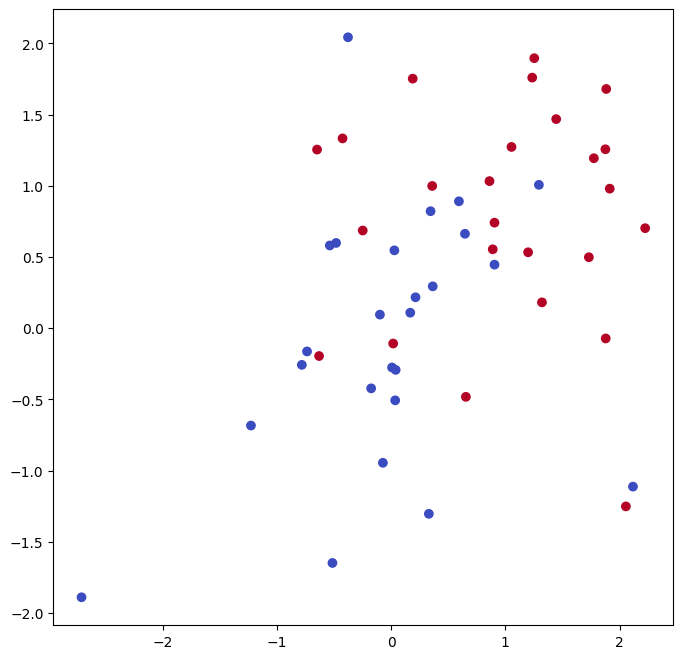

In [6]:
rng = np.random.default_rng(1)
X = rng.standard_normal((50,2))
y = np.array([-1]*25 + [1]*25)
X[y == 1] += 1
fig, ax = subplots(figsize = (8,8))
ax.scatter(X[:,0],
           X[:,1],
           c = y,
           cmap = cm.coolwarm);

In [8]:
svm_linear = SVC(C = 10, kernel = "linear")
svm_linear.fit(X, y)

SVC(C=10, kernel='linear')

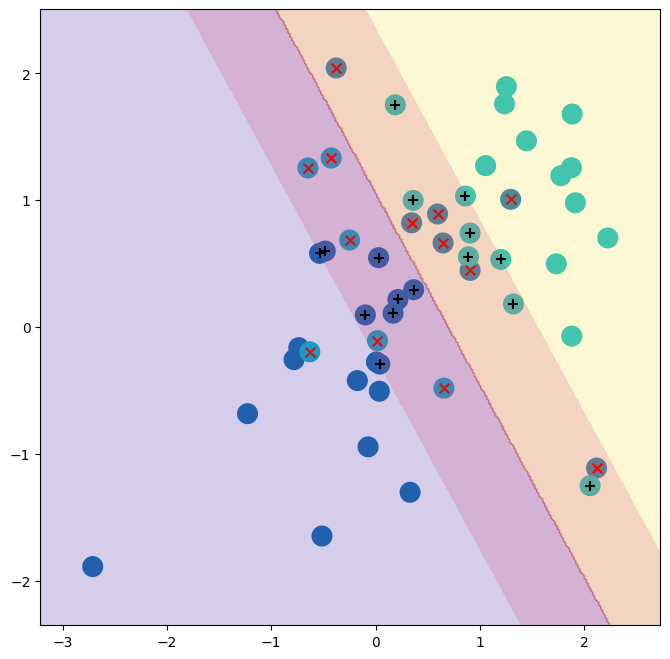

In [9]:
fig, ax = subplots(figsize = (8, 8))
plot_svm(X, 
         y,
         svm_linear,
         ax  = ax)

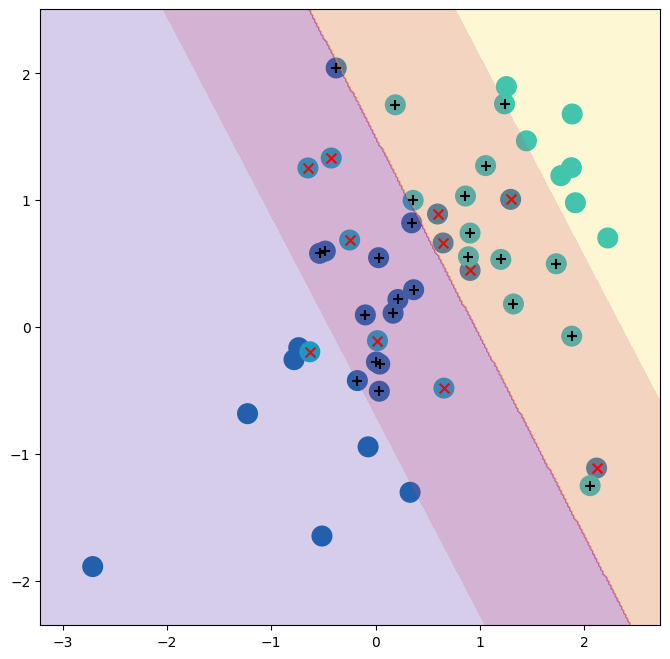

In [10]:
svm_linear_small = SVC(C = 0.1, kernel = "linear")
svm_linear_small.fit(X, y)
fig, ax = subplots(figsize =(8,8))
plot_svm(X,
         y,
         svm_linear_small,
         ax = ax)

In [12]:
svm_linear.coef_

array([[1.17303943, 0.77348227]])

In [15]:
kfold = skm.KFold(5,
                  random_state = 42,
                  shuffle = True)
grid = skm.GridSearchCV(svm_linear,
                        {"C":[0.001,0.01, 0.1, 1, 5, 10, 100]},
                        refit = True,
                        cv = kfold,
                        scoring = "accuracy")
grid.fit(X,y)
grid.best_params_

{'C': 1}

In [16]:
grid.cv_results_[("mean_test_score")]

array([0.46, 0.48, 0.72, 0.76, 0.76, 0.76, 0.76])

In [17]:
X_test = rng.standard_normal((20, 2))
y_test = np.array([-1]*10 + [1]*10)
X_test[y_test ==1] += 1

In [19]:
best = grid.best_estimator_
y_test_hat = best.predict(X_test)
confusion_table(y_test_hat, y_test)

Truth,-1,1
Predicted,,
-1,8,4
1,2,6


In [21]:
svm = SVC(C = 0.001,
          kernel = "linear").fit(X, y)
y_test_hat = svm.predict(X_test)
confusion_table(y_test_hat, y_test)

Truth,-1,1
Predicted,,
-1,2,0
1,8,10


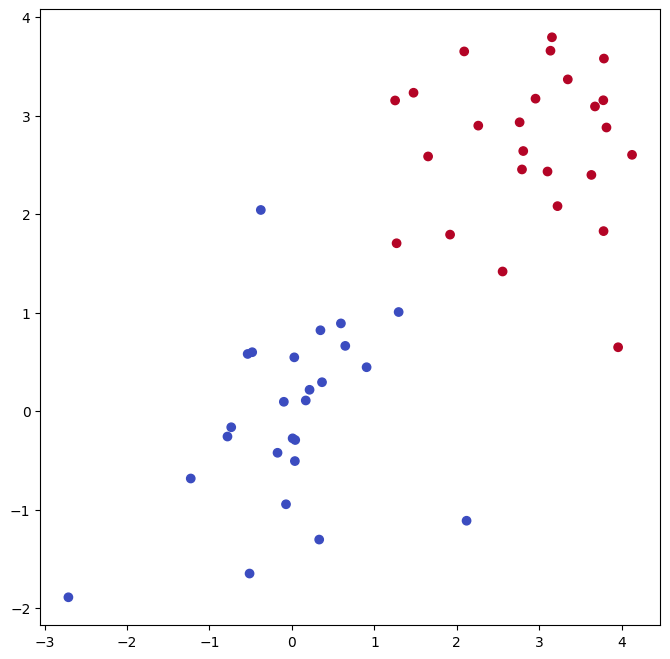

In [23]:
X[y==1] += 1.9;
fig, ax = subplots(figsize = (8, 8))
ax.scatter(X[:,0],X[:, 1], c = y, cmap = cm.coolwarm)

In [24]:
svm = SVC(C = 1e5, kernel = "linear").fit(X,y)
y_hat = svm.predict(X)
confusion_table(y_hat, y)

Truth,-1,1
Predicted,,
-1,25,0
1,0,25
